# Model Cutoffs for the KGB Model

---

## Opening the data

In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display
from matplotlib.ticker import PercentFormatter
from sklearn.metrics import confusion_matrix, roc_curve

relative_dir = Path("data") / "KGB Modelling"
project_root = next(
    (
        folder for folder in [Path.cwd(), *Path.cwd().parents]
        if (folder / relative_dir / "KGB in sample.csv").is_file()
    ),
    None,
)
if project_root is None:
    raise FileNotFoundError("Could not locate data/KGB Modelling.")

data_dir = project_root / relative_dir
in_path = data_dir / "KGB in sample.csv"
out_path = data_dir / "KGB out sample.csv"

print("In-sample:", in_path)
print("Out-of-sample:", out_path)

In-sample: c:\Users\georg\OneDrive\Coding\Origination-Scorecard\data\KGB Modelling\KGB in sample.csv
Out-of-sample: c:\Users\georg\OneDrive\Coding\Origination-Scorecard\data\KGB Modelling\KGB out sample.csv


In [10]:
# Matches the final "new_model" specification in notebook 11.
scaled = [
    "debt_to_income_ratio",
    "recent_application_count",
    "revolving_utilisation",
    "historic_defaults",
    "log_address_tenure",
]
raw_numeric = [*scaled[:-1], "disposable_income", "time_at_address_months"]
required = ["target_bad", "loan_purpose", *raw_numeric]

def load_sample(path):
    data = pd.read_csv(path, usecols=required)
    rows = data.replace(r"^\s*$", np.nan, regex=True).copy()

    for column in ["target_bad", *raw_numeric]:
        rows[column] = pd.to_numeric(rows[column], errors="raise")

    rows = rows.replace([np.inf, -np.inf], np.nan).dropna().copy()

    if not rows["target_bad"].isin([0, 1]).all() or rows["target_bad"].nunique() != 2:
        raise ValueError(f"{path.name}: target_bad must contain both 0 and 1.")
    if rows["time_at_address_months"].lt(0).any():
        raise ValueError(f"{path.name}: address tenure cannot be negative.")

    rows["low_disposable_income_flag"] = (
        rows["disposable_income"] < 150
    ).astype(float)
    rows["log_address_tenure"] = np.log1p(rows["time_at_address_months"])

    print(f"{path.name}: retained {len(rows):,}; excluded {len(data) - len(rows):,}")
    return rows

train = load_sample(in_path)
test = load_sample(out_path)

display(pd.DataFrame({
    "Sample": ["In-sample", "Out-of-sample"],
    "Accounts": [len(train), len(test)],
    "Bads": [int(train.target_bad.sum()), int(test.target_bad.sum())],
    "Observed bad rate": [train.target_bad.mean(), test.target_bad.mean()],
}).style.format({"Observed bad rate": "{:.2%}"}))

KGB in sample.csv: retained 7,258; excluded 0
KGB out sample.csv: retained 2,458; excluded 0


,Sample,Accounts,Bads,Observed bad rate
0,In-sample,7258,294,4.05%
1,Out-of-sample,2458,102,4.15%


## Fitting the model

Fitting the model to predict the bads om the sample

In [11]:
means = train[scaled].mean()
stds = train[scaled].std(ddof=0)
if not np.isfinite(stds).all() or (stds == 0).any():
    raise ValueError("A training predictor has invalid or zero variation.")

def design_matrix(rows):
    x = (rows[scaled] - means) / stds
    x.insert(0, "const", 1.0)
    x["low_disposable_income_flag"] = rows["low_disposable_income_flag"]
    x["loan_purpose=education"] = (
        rows["loan_purpose"] == "education"
    ).astype(float)
    return x.astype(float)

x_train = design_matrix(train)
x_test = design_matrix(test)
y_train = train["target_bad"].astype(int)
y_test = test["target_bad"].astype(int)

model = sm.Logit(y_train, x_train).fit(maxiter=200, disp=False)
if not model.mle_retvals.get("converged", False):
    raise RuntimeError("KGB model did not converge.")

train_pd = pd.Series(model.predict(x_train), index=train.index)
test_pd = pd.Series(model.predict(x_test), index=test.index)

print(f"In-sample mean predicted probability: {train_pd.mean():.2%}")
print(f"Out-of-sample mean predicted probability: {test_pd.mean():.2%}")

In-sample mean predicted probability: 4.05%
Out-of-sample mean predicted probability: 3.91%


,Cutoff,Training bad capture,Training good flag rate,Training KS,Out-of-sample KS,Selection
3,3.689%,67.3%,44.5%,22.88%,19.58%,Training KS maximum
2,3.500%,70.7%,50.0%,20.79%,21.22%,Comparison
4,4.000%,57.1%,36.6%,20.53%,18.90%,Comparison
5,5.000%,38.8%,21.5%,17.32%,20.59%,Comparison
1,3.000%,82.7%,66.1%,16.54%,17.93%,Comparison
6,7.500%,15.6%,6.1%,9.53%,7.01%,Comparison
0,2.000%,98.0%,94.2%,3.76%,3.21%,Comparison
7,10.000%,4.1%,1.8%,2.32%,1.03%,Comparison


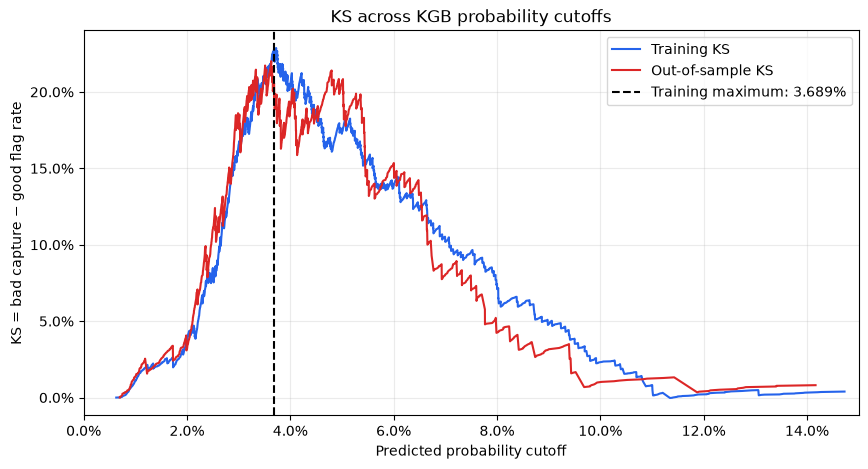

Exact training KS cutoff: 3.689076%
Maximum training KS: 22.88%


In [12]:
from sklearn.metrics import roc_curve

# Evaluate every distinct training probability as a possible cutoff.
train_fpr, train_tpr, train_thresholds = roc_curve(
    y_train, train_pd, drop_intermediate=False
)
valid = np.isfinite(train_thresholds)
valid_indices = np.flatnonzero(valid)

best_index = valid_indices[
    np.argmax((train_tpr - train_fpr)[valid])
]
best_cutoff = float(train_thresholds[best_index])

def ks_at_cutoff(actual, probability, cutoff):
    actual = np.asarray(actual)
    flagged = np.asarray(probability) >= cutoff
    bad_capture = flagged[actual == 1].mean()
    good_flag_rate = flagged[actual == 0].mean()
    return bad_capture, good_flag_rate, bad_capture - good_flag_rate

# Compare the exact training optimum with practical round-number cutoffs.
candidate_cutoffs = [
    .02, .03, .035, best_cutoff, .04, .05, .075, .10
]

rows = []
for cutoff in candidate_cutoffs:
    train_capture, train_good_flag, train_ks = ks_at_cutoff(
        y_train, train_pd, cutoff
    )
    test_capture, test_good_flag, test_ks = ks_at_cutoff(
        y_test, test_pd, cutoff
    )
    rows.append({
        "Cutoff": cutoff,
        "Training bad capture": train_capture,
        "Training good flag rate": train_good_flag,
        "Training KS": train_ks,
        "Out-of-sample KS": test_ks,
        "Selection": (
            "Training KS maximum"
            if cutoff == best_cutoff else "Comparison"
        ),
    })

ks_table = pd.DataFrame(rows).sort_values(
    "Training KS", ascending=False
)
display(ks_table.style.format({
    "Cutoff": "{:.3%}",
    "Training bad capture": "{:.1%}",
    "Training good flag rate": "{:.1%}",
    "Training KS": "{:.2%}",
    "Out-of-sample KS": "{:.2%}",
}))

# Plot KS for every achievable cutoff in each sample.
test_fpr, test_tpr, test_thresholds = roc_curve(
    y_test, test_pd, drop_intermediate=False
)

fig, ax = plt.subplots(figsize=(10, 5))
for thresholds, fpr, tpr, label, color in [
    (train_thresholds, train_fpr, train_tpr, "Training KS", "#2563eb"),
    (test_thresholds, test_fpr, test_tpr, "Out-of-sample KS", "#dc2626"),
]:
    keep = np.isfinite(thresholds) & (thresholds <= .15)
    order = np.argsort(thresholds[keep])
    ax.plot(
        thresholds[keep][order],
        (tpr - fpr)[keep][order],
        label=label,
        color=color,
    )

ax.axvline(
    best_cutoff,
    color="black",
    linestyle="--",
    label=f"Training maximum: {best_cutoff:.3%}",
)
ax.set(
    xlim=(0, .15),
    xlabel="Predicted probability cutoff",
    ylabel="KS = bad capture − good flag rate",
    title="KS across KGB probability cutoffs",
)
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.grid(alpha=.25)
ax.legend()
plt.show()

print(f"Exact training KS cutoff: {best_cutoff:.6%}")
print(f"Maximum training KS: {(train_tpr - train_fpr)[best_index]:.2%}")

I have selected based on the KS values for discriminatory power - rounded to 0.369

## Distribution for observed goods versus bads

,Sample,Observed,Accounts,P10,Median,P90,Mean
0,In-sample,Good (0),6964,2.24%,3.50%,6.47%,4.01%
1,In-sample,Bad (1),294,2.55%,4.35%,8.40%,5.03%
2,Out-of-sample,Good (0),2356,2.20%,3.45%,6.14%,3.87%
3,Out-of-sample,Bad (1),102,2.62%,4.11%,7.70%,4.84%


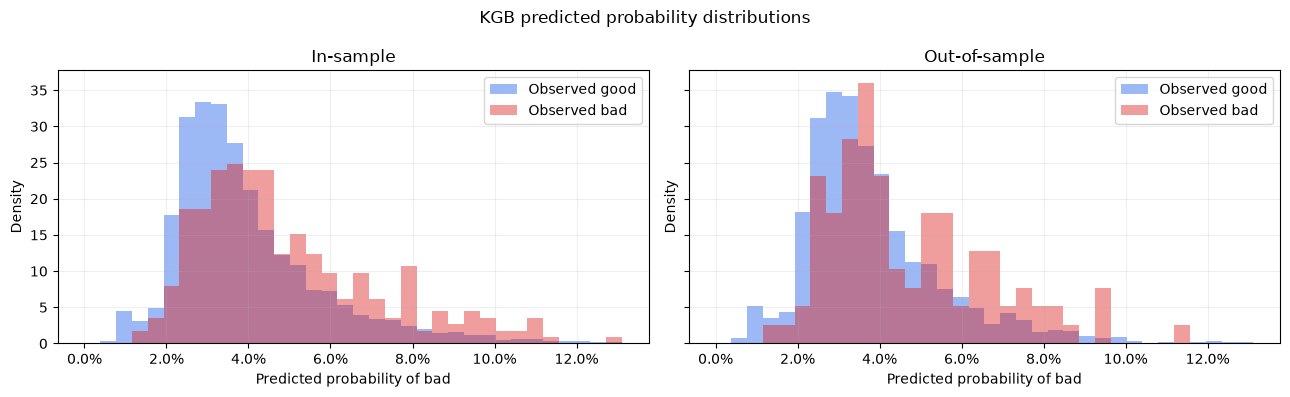

The chart trims the far right tail; the tables include all accounts.


In [13]:
summary = pd.DataFrame([
    {
        "Sample": sample,
        "Observed": label,
        "Accounts": int(mask.sum()),
        "P10": probabilities.loc[mask].quantile(.10),
        "Median": probabilities.loc[mask].median(),
        "P90": probabilities.loc[mask].quantile(.90),
        "Mean": probabilities.loc[mask].mean(),
    }
    for sample, actual, probabilities in [
        ("In-sample", y_train, train_pd),
        ("Out-of-sample", y_test, test_pd),
    ]
    for label, mask in [
        ("Good (0)", actual.eq(0)),
        ("Bad (1)", actual.eq(1)),
    ]
])
display(summary.style.format({
    "P10": "{:.2%}", "Median": "{:.2%}",
    "P90": "{:.2%}", "Mean": "{:.2%}",
}))

# Density allows the shapes to be compared despite the smaller bad population.
upper = max(train_pd.quantile(.995), test_pd.quantile(.995))
edges = np.linspace(0, max(.01, upper), 35)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, sample, actual, probabilities in [
    (axes[0], "In-sample", y_train, train_pd),
    (axes[1], "Out-of-sample", y_test, test_pd),
]:
    for value, label, color in [
        (0, "Observed good", "#2563eb"),
        (1, "Observed bad", "#dc2626"),
    ]:
        ax.hist(
            probabilities.loc[actual.eq(value)],
            bins=edges,
            density=True,
            alpha=.45,
            label=label,
            color=color,
        )
    ax.set(
        title=sample,
        xlabel="Predicted probability of bad",
        ylabel="Density",
    )
    ax.xaxis.set_major_formatter(PercentFormatter(1))
    ax.grid(alpha=.2)
    ax.legend()

fig.suptitle("KGB predicted probability distributions")
fig.tight_layout()
plt.show()
print("The chart trims the far right tail; the tables include all accounts.")

In [14]:
band_edges = [0, .01, .02, .03, .05, .075, .10, .15, .20, .30, .50, 1.000001]
bands = pd.DataFrame({
    "pd": test_pd.to_numpy(),
    "bad": y_test.to_numpy(),
})
bands["PD band"] = pd.cut(
    bands["pd"], bins=band_edges, include_lowest=True, right=False
)

band_table = (
    bands.groupby("PD band", observed=False)
    .agg(
        Accounts=("bad", "size"),
        Bads=("bad", "sum"),
        Mean_predicted_PD=("pd", "mean"),
        Observed_bad_rate=("bad", "mean"),
    )
    .reset_index()
)
band_table["Share of accounts"] = band_table["Accounts"] / len(bands)
band_table["Share of all bads"] = band_table["Bads"] / y_test.sum()

display(band_table.style.format({
    "Mean_predicted_PD": "{:.2%}",
    "Observed_bad_rate": "{:.2%}",
    "Share of accounts": "{:.1%}",
    "Share of all bads": "{:.1%}",
}, na_rep="—"))

,PD band,Accounts,Bads,Mean_predicted_PD,Observed_bad_rate,Share of accounts,Share of all bads
0,"[0.0, 0.01)",33,0,0.87%,0.00%,1.3%,0.0%
1,"[0.01, 0.02)",115,3,1.54%,2.61%,4.7%,2.9%
2,"[0.02, 0.03)",684,14,2.56%,2.05%,27.8%,13.7%
3,"[0.03, 0.05)",1123,44,3.78%,3.92%,45.7%,43.1%
4,"[0.05, 0.075)",379,29,5.95%,7.65%,15.4%,28.4%
5,"[0.075, 0.1)",100,10,8.47%,10.00%,4.1%,9.8%
6,"[0.1, 0.15)",20,1,11.89%,5.00%,0.8%,1.0%
7,"[0.15, 0.2)",4,1,18.04%,25.00%,0.2%,1.0%
8,"[0.2, 0.3)",0,0,—,—,0.0%,0.0%
9,"[0.3, 0.5)",0,0,—,—,0.0%,0.0%


---

## Comparing possible cutoffs

In [15]:
# Training KS cutoff maximises bad capture minus good-account flag rate.
fpr, tpr, roc_cutoffs = roc_curve(y_train, train_pd)
finite = np.isfinite(roc_cutoffs)
ks_index = np.flatnonzero(finite)[np.argmax((tpr - fpr)[finite])]
ks_cutoff = float(roc_cutoffs[ks_index])

candidate_cutoffs = sorted(set(np.round([
    .01, .02, .03, .04, .05, .075, .10, .15, .20, ks_cutoff
], 6)))

def cutoff_metrics(actual, probability, cutoff):
    predicted_bad = np.asarray(probability) >= cutoff
    tn, fp, fn, tp = confusion_matrix(
        actual, predicted_bad, labels=[0, 1]
    ).ravel()
    flagged = tp + fp
    below = tn + fn

    return {
        "Cutoff": cutoff,
        "Flagged accounts": flagged,
        "Flagged share": flagged / len(actual),
        "Bads flagged": tp,
        "Bad capture": tp / (tp + fn),
        "Goods flagged": fp,
        "Good flag rate": fp / (fp + tn),
        "Bads below cutoff": fn,
        "Bad rate flagged": tp / flagged if flagged else np.nan,
        "Bad rate below": fn / below if below else np.nan,
    }

cutoff_table = pd.DataFrame([
    cutoff_metrics(y_test, test_pd, cutoff)
    for cutoff in candidate_cutoffs
])

display(cutoff_table.style.format({
    "Cutoff": "{:.2%}",
    "Flagged share": "{:.1%}",
    "Bad capture": "{:.1%}",
    "Good flag rate": "{:.1%}",
    "Bad rate flagged": "{:.2%}",
    "Bad rate below": "{:.2%}",
}, na_rep="—"))

print(f"Training KS cutoff: {ks_cutoff:.2%}")
print("At or above cutoff = predicted bad / flagged.")
print("Below cutoff = predicted good.")

,Cutoff,Flagged accounts,Flagged share,Bads flagged,Bad capture,Goods flagged,Good flag rate,Bads below cutoff,Bad rate flagged,Bad rate below
0,1.00%,2425,98.7%,102,100.0%,2323,98.6%,0,4.21%,0.00%
1,2.00%,2310,94.0%,99,97.1%,2211,93.8%,3,4.29%,2.03%
2,3.00%,1626,66.2%,85,83.3%,1541,65.4%,17,5.23%,2.04%
3,3.69%,1081,44.0%,64,62.7%,1017,43.2%,38,5.92%,2.76%
4,4.00%,880,35.8%,55,53.9%,825,35.0%,47,6.25%,2.98%
5,5.00%,503,20.5%,41,40.2%,462,19.6%,61,8.15%,3.12%
6,7.50%,124,5.0%,12,11.8%,112,4.8%,90,9.68%,3.86%
7,10.00%,24,1.0%,2,2.0%,22,0.9%,100,8.33%,4.11%
8,15.00%,4,0.2%,1,1.0%,3,0.1%,101,25.00%,4.12%
9,20.00%,0,0.0%,0,0.0%,0,0.0%,102,—,4.15%


Training KS cutoff: 3.69%
At or above cutoff = predicted bad / flagged.
Below cutoff = predicted good.


3.69 Chosen in order to maximise the dev samples KS statistic

---

## Inspecting the chosen cutoff

In [16]:
chosen_cutoff = ks_cutoff  # Replace with a cutoff you want to examine.
predicted_bad = test_pd.ge(chosen_cutoff).astype(int)

display(pd.DataFrame(
    confusion_matrix(y_test, predicted_bad, labels=[0, 1]),
    index=["Observed good (0)", "Observed bad (1)"],
    columns=["Predicted good / below", "Predicted bad / flagged"],
))

display(pd.DataFrame([
    cutoff_metrics(y_test, test_pd, chosen_cutoff)
]).style.format({
    "Cutoff": "{:.2%}",
    "Flagged share": "{:.1%}",
    "Bad capture": "{:.1%}",
    "Good flag rate": "{:.1%}",
    "Bad rate flagged": "{:.2%}",
    "Bad rate below": "{:.2%}",
}))

,Predicted good / below,Predicted bad / flagged
Observed good (0),1339,1017
Observed bad (1),38,64


,Cutoff,Flagged accounts,Flagged share,Bads flagged,Bad capture,Goods flagged,Good flag rate,Bads below cutoff,Bad rate flagged,Bad rate below
0,3.69%,1081,44.0%,64,62.7%,1017,43.2%,38,5.92%,2.76%


Looks to high here, flagging too many goods, too many false positives here. Look to reduce this